In [1]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.temporal_pc_stacking_kalman_vel_filter_tb import temporalVelFilteringStackedTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker


/home/david/.cache/pypoetry/virtualenvs/odometry-u_DtWola-py3.11/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
dataset = radnavDS(
    dataset_path=DATASET_PATH + "/WILK/WILK_vel_cfg_1",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

found 1156 radar samples
found 1156 lidar samples
found 1156 camera samples
found 1156 imu (orientation only) samples
found 1156imu (full data) samples
found 1156 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [3]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1,#originally 0.5
    icp_best_points_percentile=65, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=1.5 #originally 0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6, #originally 0.6
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

In [4]:
#initialize the point cloud stacker
pc_stacker = temporalPcStacker(
    num_frames_static_history = 4,
    num_frames_dynamic_history = 0,
    refresh_distance_m = 3,
    refresh_rot_deg = 180,
    refresh_time_s = 10,
    grid_resolution_m = 5e-2,
    grid_max_distance_m = 20,
    multi_path_clustering_eps = 0.5,
    multi_path_clustering_min_samples = 15,
    vel_filtering_enabled = True,
    vel_filtering_v_thresh = 0.1,
    vel_filtering_min_static_rejection_radius = 0.5,
    vel_filtering_dynamic_cluster_eps = 1.0,
    vel_filtering_dynamic_cluster_min_samples = 15,
    min_detection_radius_m=1.0,
    max_detection_range_m=20
)

loaded map with 20750 points
loaded map with 20750 points
gt icp estimated heading:-2.250520360363415 deg, pose:[-0.24535722 -0.10065003]
radar icp estimated heading:-1.5651671078084293 deg, pose:[ 0.09035581 -0.13289832]


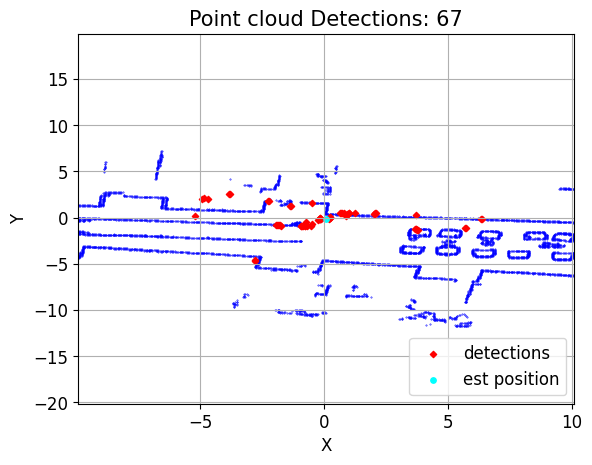

In [5]:
test_bench = temporalVelFilteringStackedTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    pc_stacker=pc_stacker
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=start_heading,
    est_start_position_m=start_pose,
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

#initialize the point cloud stacker
test_bench.init_pc_stacker(
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


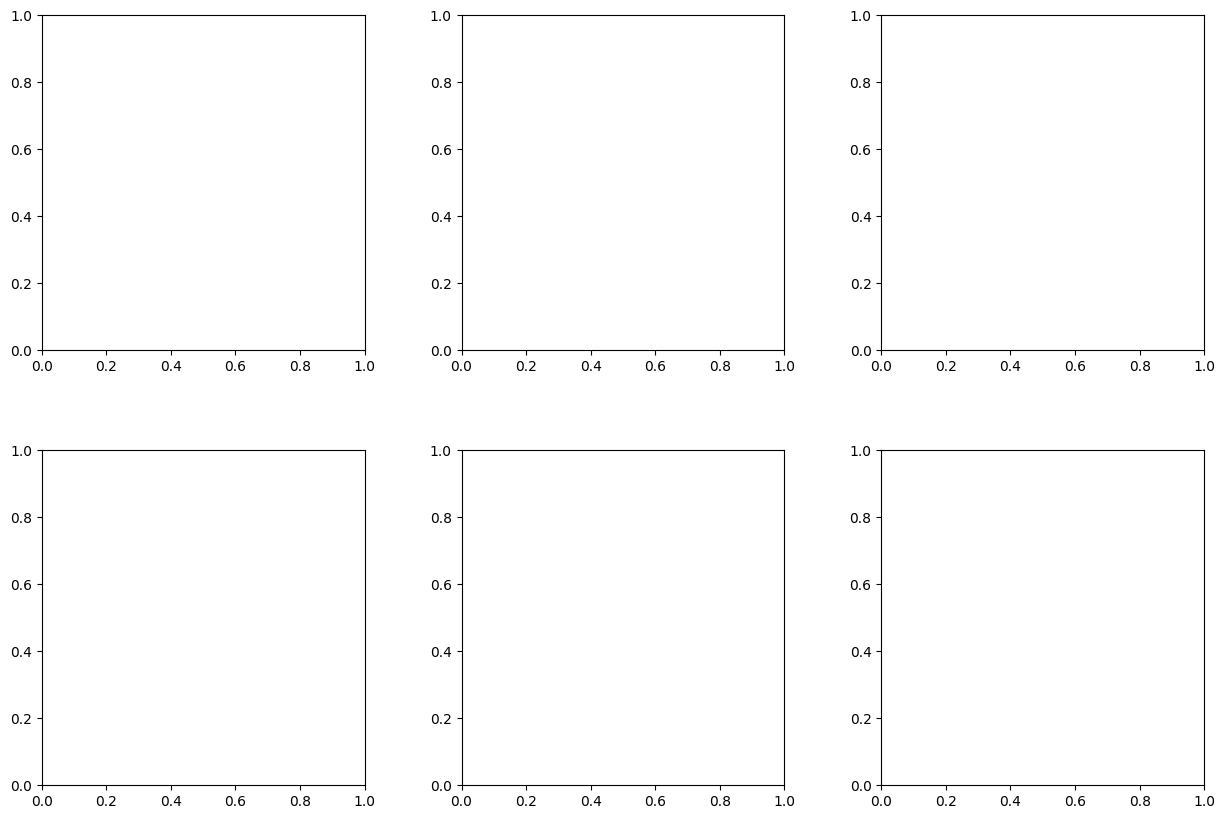

In [6]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [7]:
end_idx = 530
save_name = "WILK_vel_cfg_1_radar_0"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True,
    movie_generator=None) #=movie_generator)

100%|██████████| 530/530 [00:45<00:00, 11.71it/s]


In [8]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

0it [00:00, ?it/s]


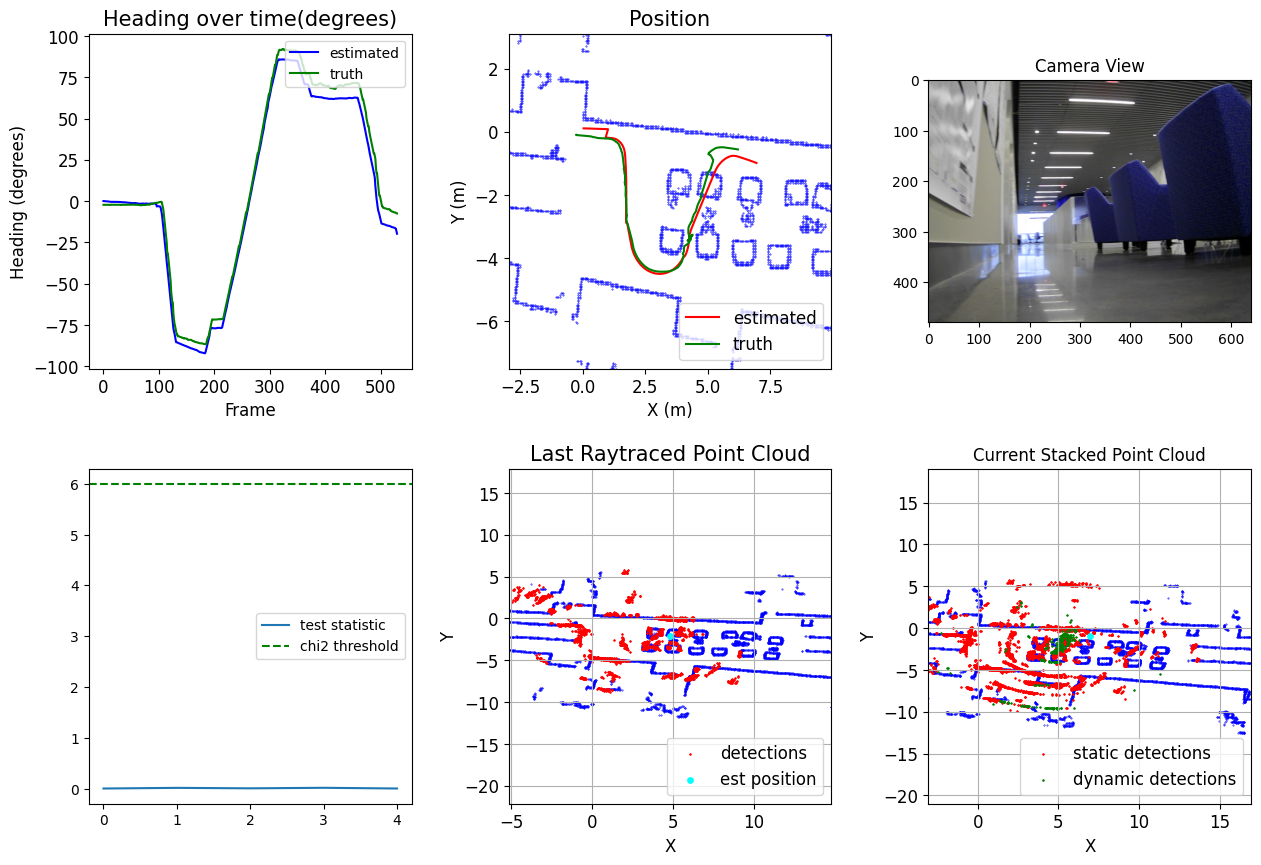

In [9]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

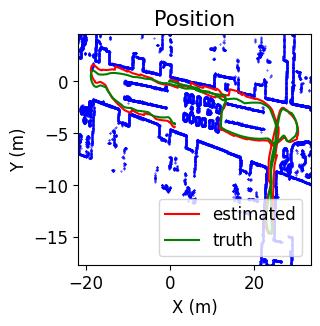

In [752]:
test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    show=True
)

In [753]:
print(test_bench.filter.x[0:3])
print(test_bench.gt_localizer.current_pose_m)
print(test_bench.point_cloud_stacker.integrator.x[0:3])
print(test_bench.point_cloud_stacker.initial_pose_m)
print(test_bench.point_cloud_stacker.current_pose_m)
print(np.linalg.norm(test_bench.gt_localizer.current_pose_m - test_bench.filter.x[0:2]))

[ 1.02711777 -4.36644048 12.42508525]
[ 1.13703892 -4.10575276]
[ 3.92889792  5.64740636 11.48688984]
[3.92889792 5.64740636]
[3.92889792 5.64740636]
0.2829147300964738


In [754]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

135.4762321223168


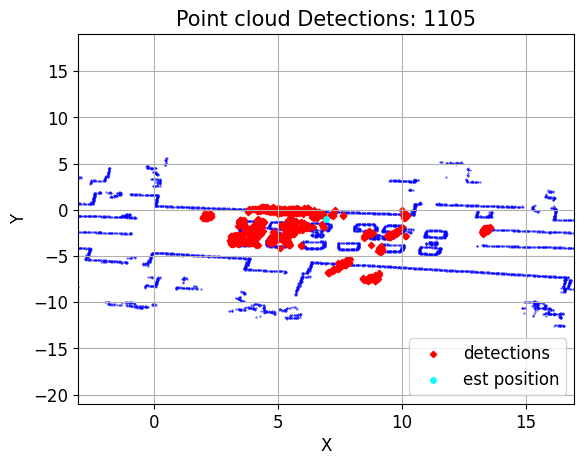

In [237]:
#debugging temporal pc stack
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

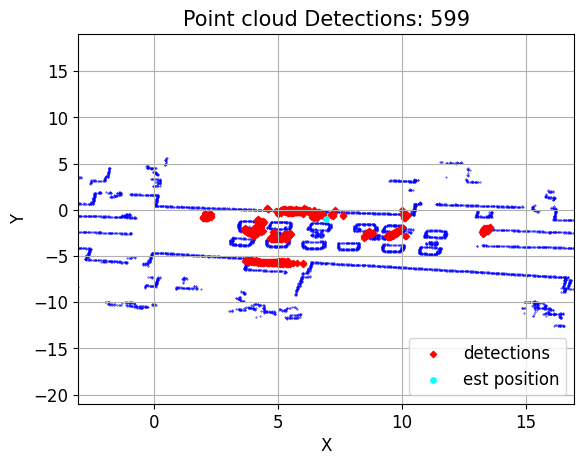

In [239]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

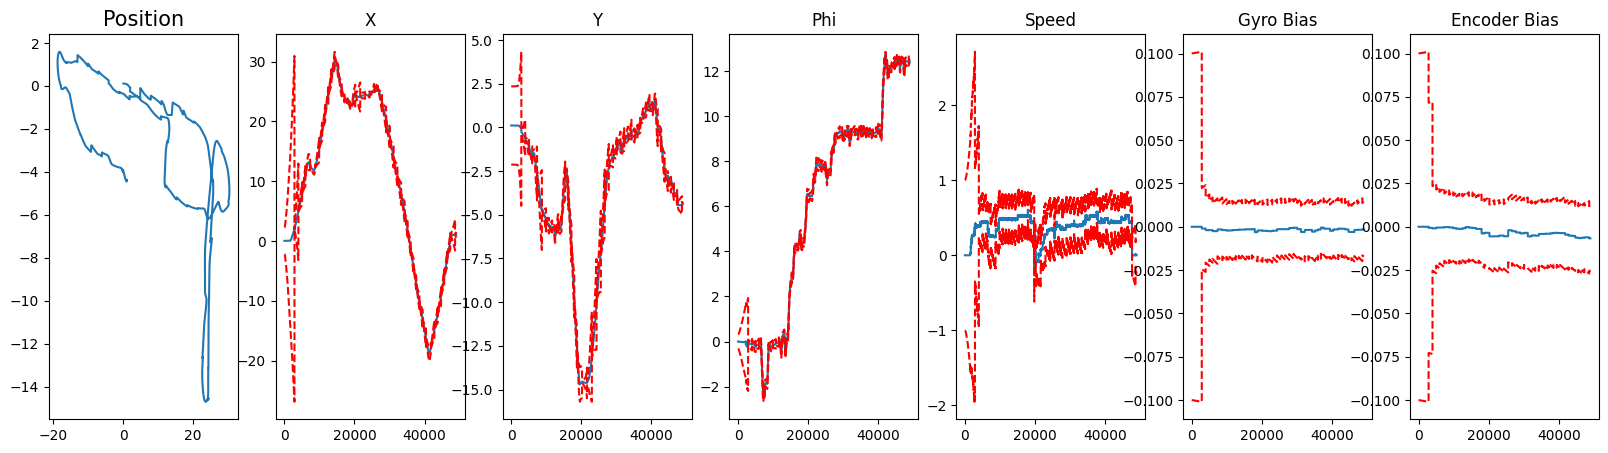

In [757]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)

100%|██████████| 3/3 [00:00<00:00, 274.80it/s]


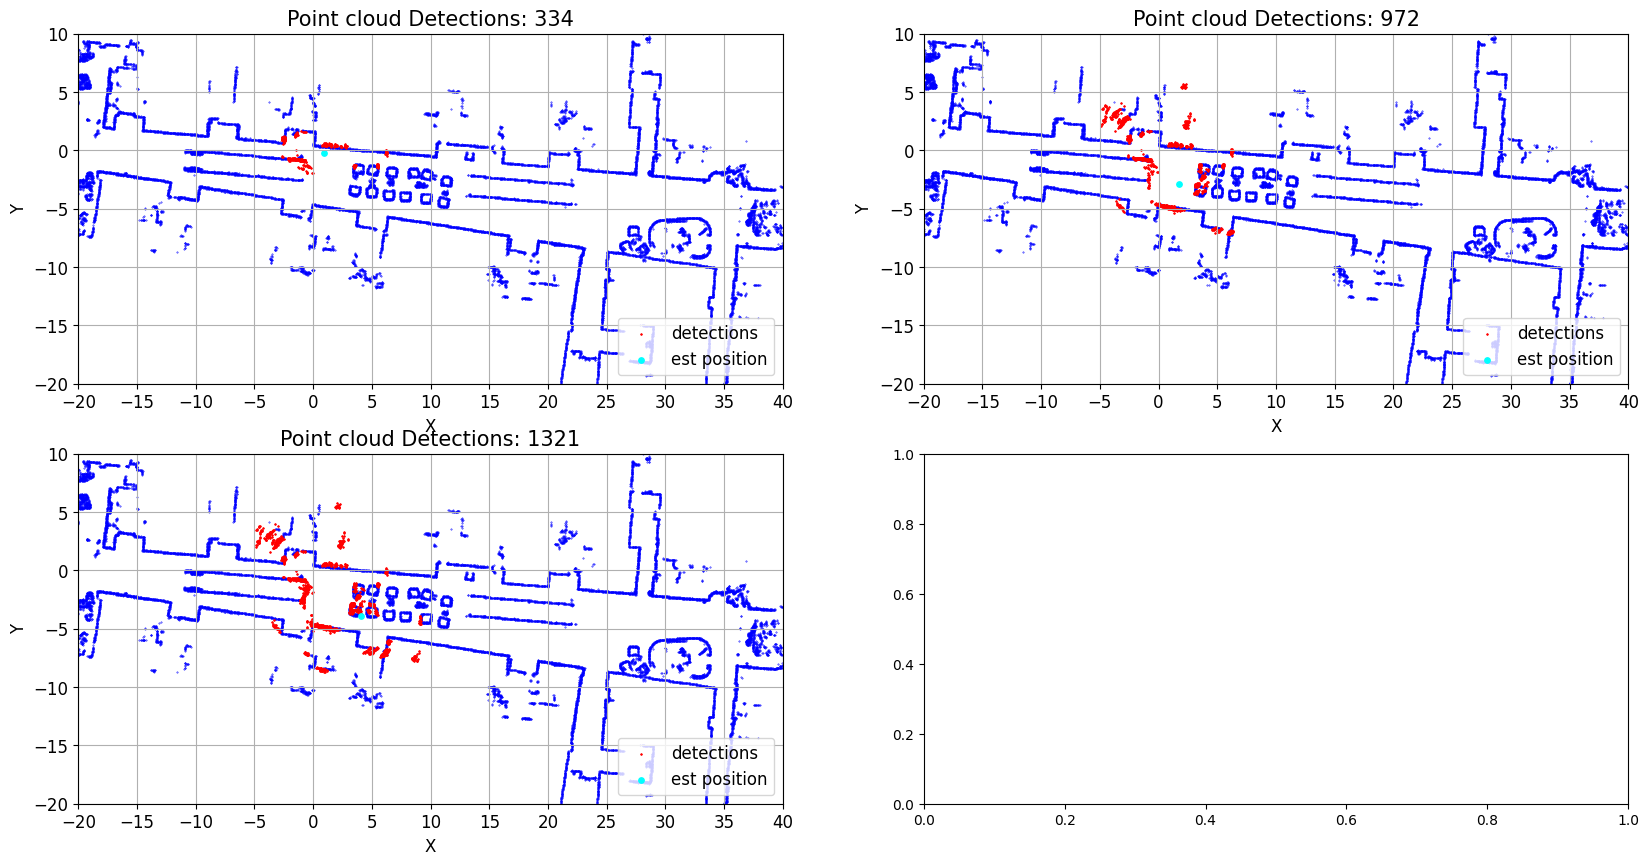

In [188]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

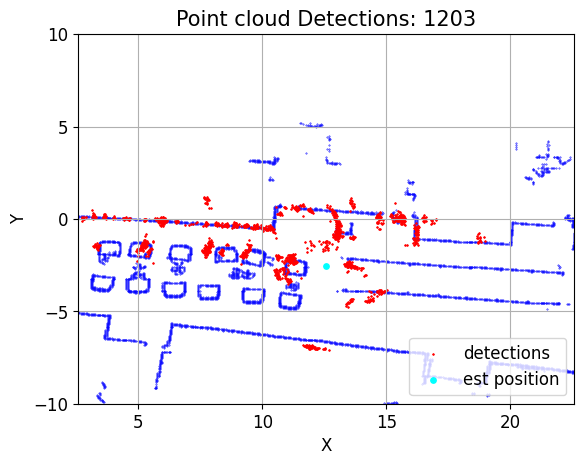

In [759]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [760]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,0.433765,-0.071495,-0.046417,-0.080147
1,Variance,0.104183,0.198546,0.086523,0.002621
2,Median,0.343507,-0.044147,0.022296,-0.083568
3,0.9th percentile,0.783409,0.665251,0.510332,0.150976


## Debugging (testing ray tracing)

In [10]:

from odometry.point_cloud_processing.vel_filtering import VelFiltering

if(test_bench.point_cloud_stacker.vel_filtering_enabled):
    detections = dataset.get_radar_detections(idx)
    ego_x_vel = dataset.get_vehicle_vel_data(idx)[0,1]
    vehicle_vel = np.array([ego_x_vel,0.0])
        
    dynamic_objects = test_bench.point_cloud_stacker.vel_filtering.get_dynamic_detections(detections,vehicle_vel)
    print(dynamic_objects)
else:
    print("Velocity Filtering Disabled")

NameError: name 'idx' is not defined

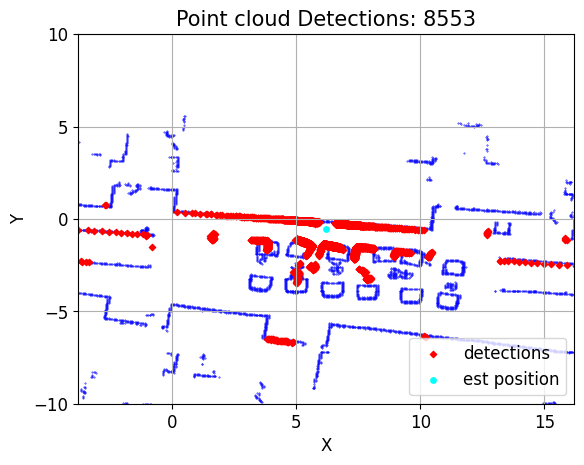

In [11]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

2.4082893271280263
9.73669958114624


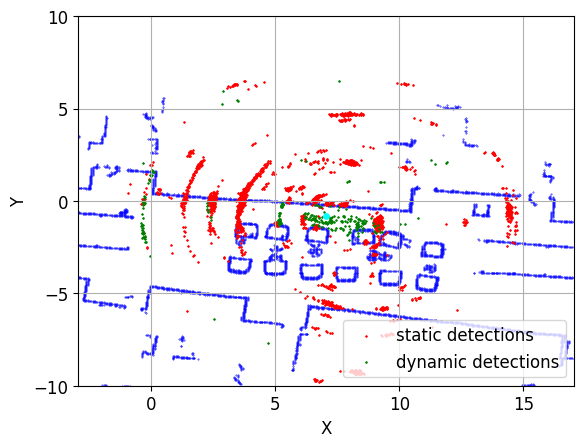

In [13]:
#recenter the point cloud grids



combined_point_cloud = test_bench.point_cloud_stacker._get_points_from_pc_grid(
    test_bench.point_cloud_stacker.pc_grid_static[0]
)
dynamic_combined_point_cloud = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    test_bench.point_cloud_stacker.pc_grid_dynamic
)
print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_point_cloud,
    dynamic_points = dynamic_combined_point_cloud,
    heading_rad = test_bench.point_cloud_stacker.current_heading_rad,
    pose_m= test_bench.point_cloud_stacker.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
from odometry.point_cloud_processing.multipath import MultiPath
from odometry.supportFns import rotation_functions
from odometry.supportFns import coordinate_systems

idx=500

stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
dynamic_stacked_pc_cart = test_bench.dynamic_point_cloud_stacker.get_points()

multipath = MultiPath(
    clustering_eps=0.5,
    clustering_min_samples=15
)

dynamic_multipath = MultiPath(
    clustering_eps=0.5,
    clustering_min_samples=15
)

labels = multipath._cluster_points(stacked_pc_cart)
if(np.any(dynamic_stacked_pc_cart)):
    dynamic_labels = dynamic_multipath._cluster_points(dynamic_stacked_pc_cart)

    # plot the lidar point cloud
    fig,ax = plt.subplots()
    test_bench.plotter_localization.marker_size=0.5
    test_bench.plotter_localization.plot_dynamic_and_static_detection_clusters_on_map(
        static_points=stacked_pc_cart,
        dynamic_points=dynamic_stacked_pc_cart,
        labels=labels,
        dynamic_labels=dynamic_labels,
        heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
        pose_m=test_bench.point_cloud_stacker.current_pose_m,
        ax=ax,
        plot_raw_detections=False,
        show=False
    )
else:
    fig,ax = plt.subplots()
    test_bench.plotter_localization.marker_size=0.5
    test_bench.plotter_localization.plot_detection_clusters_on_map(
        current_points=stacked_pc_cart,
        labels=labels,
        heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
        pose_m=test_bench.point_cloud_stacker.current_pose_m,
        ax=ax,
        plot_raw_detections=False,
        show=False
    )

ax.set_ylim(-10,10)
plt.show()

In [ ]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
    valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

In [ ]:
test_bench.plotter_localization.plot_detections(
    stacked_pc_cart,
    show=True
)

In [ ]:
labels = test_bench.multipath._cluster_points(stacked_pc_cart)

print(np.unique(labels))
cluster_to_plot = 6
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart[labels==cluster_to_plot],
    labels=labels[labels==cluster_to_plot],
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

In [ ]:
pc_polar = coordinate_systems.cartesian_to_polar(stacked_pc_cart)
#enable tracking for labels and valid points
unique_labels = np.unique(labels)[1:] #remove the -1 label
valid_points = np.ones(pc_polar.shape[0],dtype=bool)
#handle points already not in a cluster
valid_points[labels==-1] = 0

#for each cluster determine the range of its closest point
cluster_ranges = np.array([
    np.min(pc_polar[labels==cluster_id,0]) for \
    cluster_id in unique_labels
])

#sort the clusters by their ranges
sorted_idxs = np.argsort(cluster_ranges)


cluster_idx = 9
cluster_points = pc_polar[labels==unique_labels[cluster_idx]]

#get the maximum range and angle bounds of the cluster
angle_bounds = [np.min(cluster_points[:,1]),np.max([cluster_points[:,1]])]
max_range = np.max(cluster_points[:,0])
print("original angle bounds: {}, range: {}".format(angle_bounds,max_range))

#handle special case where points are clustered around -pi,pi
if angle_bounds[1] - angle_bounds[0] > np.pi: #assume no cluster occupies more than +pi
    #determine the correct bounds

    #set the positive bound
    angle_bounds[1] = np.min(cluster_points[cluster_points[:,1] > 0,1])
    #set the negative bound
    angle_bounds[0] = np.max(cluster_points[cluster_points[:,1] < 0,1])

    print("new angle bounds: {}, range: {}".format(angle_bounds,max_range))

    #identify indicies of points that are past these points
    invalid_idxs = \
        (pc_polar[:,0] > max_range) & \
        ((pc_polar[:,1] > angle_bounds[1]) | \
        (pc_polar[:,1] < angle_bounds[0]))
else: #standard case
    invalid_idxs = \
        (pc_polar[:,0] > max_range) & \
        (pc_polar[:,1] < angle_bounds[1]) & \
        (pc_polar[:,1] > angle_bounds[0])

valid_points[invalid_idxs] = 0

valid_stacked_pc_cart = stacked_pc_cart[valid_points,:]

test_bench.plotter_localization.plot_detections(
    valid_stacked_pc_cart,
    show=True
)


In [ ]:
#get the remaining valid points and re-cluster them
valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [ ]:
#perform an ICP update
test_bench.localizer.icp_best_points_percentile = 95
est_heading_rad,est_pose_m = test_bench.localizer.update_odometry(
    points=valid_stacked_pc_cart,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
)

print("Filter estimate: heading: {} rad, pose: {} m".format(
    test_bench.filter.x[2],
    np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
))
print("New estimate: heading: {} rad, pose: {} m".format(
    est_heading_rad,est_pose_m
))
print("GT: heading: {} rad, pose: {} m".format(
    test_bench.gt_localizer.current_heading_rad,
    test_bench.gt_localizer.current_pose_m
))

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=est_heading_rad,
    pose_m=est_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show